### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [19]:
import cv2
import time
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt

### Step 2: Constant

In [3]:
PRETIME = 0
CURTIME = 0
WIDTH = 600
HEIGHT = 800

### Step 2: Initializing Holistic Model

In [4]:
mp_holistic = mp.solutions.holistic

In [5]:
holistic_model = mp_holistic.Holistic(
    
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

In [6]:
mp_drawing = mp.solutions.drawing_utils

### Step 3: Detecting Face and Hand landmarks

In [21]:
show_image = None

In [22]:
capture = cv2.VideoCapture(0)
while capture.isOpened():
    ret, frame = capture.read()
    if not ret:
        continue
    frame = cv2.resize(frame, (HEIGHT, WIDTH))

    frame.flags.writeable = False
    results = holistic_model.process(frame)
    frame.flags.writeable = True

    # # Face
    if results.face_landmarks:
        mp_drawing.draw_landmarks(
            frame,
            results.face_landmarks,
            mp_holistic.FACEMESH_CONTOURS,
            mp_drawing.DrawingSpec(
                color=(255,0,255),
                thickness=1,
                circle_radius=1
            ),
            mp_drawing.DrawingSpec(
                color=(0,255,255),
                thickness=1,
                circle_radius=1
            )
        )

    # right hand
    if results.right_hand_landmarks:
        mp_drawing.draw_landmarks(
          frame, 
          results.right_hand_landmarks, 
          mp_holistic.HAND_CONNECTIONS
        )

    # left hand
    if results.left_hand_landmarks:
        mp_drawing.draw_landmarks(
          frame, 
          results.left_hand_landmarks, 
          mp_holistic.HAND_CONNECTIONS
        )

    CURTIME = time.time()
    fps = 1 / (CURTIME-PRETIME)
    PRETIME = CURTIME

    cv2.putText(
        frame,
        str(int(fps))+" FPS", 
        (10, 70), 
        cv2.FONT_HERSHEY_COMPLEX, 
        1, 
        (0,255,0), 
        2
    )
    
    cv2.imshow("Facial and Hand Landmarks", frame)

    if results.face_landmarks and results.right_hand_landmarks and results.left_hand_landmarks:
        show_image = frame
        
    if cv2.waitKey(5) & 0xFF == ord('q'):
        break

capture.release()
cv2.destroyAllWindows()

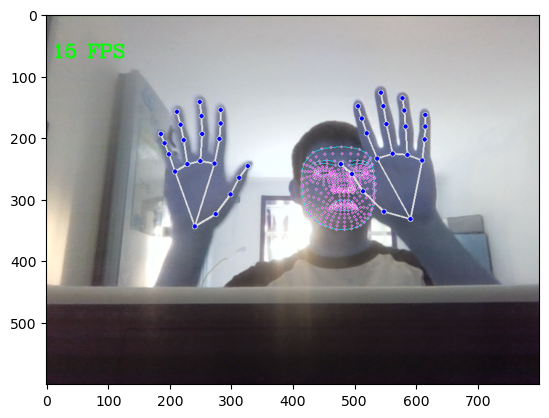

In [23]:
plt.imshow(show_image)